## Model 3: XGBoost on Synthetic Neonatal Clinical Data

### **Purpose:** Predict respiratory distress risk from clinical variables only

### **Data:** Synthetic neonatal dataset (30,000 records)

### **Output:** P(y|X_clinical) - probability of respiratory distress

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import warnings
warnings.filterwarnings('ignore')

## 2. Load Synthetic Neonatal Data

In [2]:
data_dir = Path("../../clinical_data")

# Load all three burden scenarios
df_low = pd.read_csv(data_dir / "neonatal_low_burden.csv")
df_moderate = pd.read_csv(data_dir / "neonatal_moderate_burden.csv")
df_high = pd.read_csv(data_dir / "neonatal_high_burden.csv")

print("="*60)
print("SYNTHETIC NEONATAL DATA LOADED")
print("="*60)
print(f"Low burden: {len(df_low):,} samples")
print(f"Moderate burden: {len(df_moderate):,} samples")
print(f"High burden: {len(df_high):,} samples")
print(f"\nTOTAL: {len(df_low) + len(df_moderate) + len(df_high):,} samples")

# Combine all scenarios (we'll use moderate for training, others for testing)
df = pd.concat([df_low, df_moderate, df_high], ignore_index=True)
print(f"\nCombined shape: {df.shape}")

# Display first few rows
df.head()

SYNTHETIC NEONATAL DATA LOADED
Low burden: 10,000 samples
Moderate burden: 10,000 samples
High burden: 10,000 samples

TOTAL: 30,000 samples

Combined shape: (30000, 17)


,id,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,primary_outcome
0,1,F,36.3,2860,39.8,24,2,vaginal,7,6,36.8,134,45,97,Normal_BW,Late_preterm,healthy
1,2,M,37.8,2640,34.0,15,0,vaginal,9,9,36.5,144,53,95,Normal_BW,Term,healthy
2,3,F,39.6,3010,41.4,27,1,vaginal,9,10,37.2,149,55,98,Normal_BW,Term,healthy
3,4,F,39.0,3230,34.6,31,4,vaginal,9,9,36.7,160,51,98,Normal_BW,Term,healthy
4,5,M,39.0,3630,35.2,27,0,caesarean,9,9,36.9,147,43,98,Normal_BW,Term,healthy


## 3. Explore dataset structure

In [3]:
print("\nColumn names:")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col}")

print(f"\nData types:")
print(df.dtypes)

print(f"\nMissing values:")
print(df.isnull().sum())


Column names:
  1. id
  2. sex
  3. gestational_age_weeks
  4. birth_weight_g
  5. head_circumference_cm
  6. maternal_age_years
  7. parity
  8. delivery_mode
  9. apgar_1min
  10. apgar_5min
  11. temperature_c
  12. heart_rate_bpm
  13. respiratory_rate_bpm
  14. spo2_percent
  15. bw_category
  16. preterm_category
  17. primary_outcome

Data types:
id                         int64
sex                       object
gestational_age_weeks    float64
birth_weight_g             int64
head_circumference_cm    float64
maternal_age_years         int64
parity                     int64
delivery_mode             object
apgar_1min                 int64
apgar_5min                 int64
temperature_c            float64
heart_rate_bpm             int64
respiratory_rate_bpm       int64
spo2_percent               int64
bw_category               object
preterm_category          object
primary_outcome           object
dtype: object

Missing values:
id                       0
sex                     

## 4. Define Features and Target

In [4]:
print("\n Target distribution in each dataset:")

# Process each dataframe separately
dataframes = {
    'moderate': df_moderate,
    'low': df_low,
    'high': df_high
}

for name, df_temp in dataframes.items():
    print(f"\n{name.upper()} BURDEN:")
    print(df_temp['primary_outcome'].value_counts())
    
    # Create binary target
    df_temp['target'] = (df_temp['primary_outcome'] == 'respiratory_distress').astype(int)
    
    # Create categorical features if they exist
    if 'sex' in df_temp.columns:
        df_temp['sex_male'] = (df_temp['sex'] == 'M').astype(int)
        print(f"\n Created 'sex_male' for {name}")
    
    if 'delivery_mode' in df_temp.columns:
        df_temp['delivery_mode_csection'] = (df_temp['delivery_mode'] == 'caesarean').astype(int)
        print(f" Created 'delivery_mode_csection' for {name}")

# Base clinical features
base_feature_columns = [
    'gestational_age_weeks',
    'birth_weight_g',
    'apgar_1min',
    'apgar_5min',
    'heart_rate_bpm',
    'respiratory_rate_bpm',
    'spo2_percent',
    'temperature_c',
    'maternal_age_years',
    'parity'
]

# Build final feature list
feature_columns = base_feature_columns.copy()

# Add categorical features if they exist in the dataframes
if 'sex_male' in df_moderate.columns:
    feature_columns.append('sex_male')
if 'delivery_mode_csection' in df_moderate.columns:
    feature_columns.append('delivery_mode_csection')

print(f"\n Final feature columns ({len(feature_columns)}):")
for f in feature_columns:
    print(f"  - {f}")

# Verify all features exist in all dataframes
for name, df_temp in dataframes.items():
    missing = [col for col in feature_columns if col not in df_temp.columns]
    if missing:
        print(f"\n Warning: {name} missing columns: {missing}")
    else:
        print(f"\n {name} has all features")


 Target distribution in each dataset:

MODERATE BURDEN:
primary_outcome
healthy                  8001
low_birth_weight_term     489
preterm_complications     478
birth_asphyxia            423
neonatal_sepsis           350
respiratory_distress      259
Name: count, dtype: int64

 Created 'sex_male' for moderate
 Created 'delivery_mode_csection' for moderate

LOW BURDEN:
primary_outcome
healthy                  8864
low_birth_weight_term     351
preterm_complications     311
birth_asphyxia            253
neonatal_sepsis           147
respiratory_distress       74
Name: count, dtype: int64

 Created 'sex_male' for low
 Created 'delivery_mode_csection' for low

HIGH BURDEN:
primary_outcome
healthy                  7001
birth_asphyxia            715
low_birth_weight_term     704
preterm_complications     670
neonatal_sepsis           509
respiratory_distress      401
Name: count, dtype: int64

 Created 'sex_male' for high
 Created 'delivery_mode_csection' for high

 Final feature columns (

## 5. Train/Val/Test Split (Stratified by Burden)

In [5]:
# Extract features from each dataframe
X_train = df_moderate[feature_columns].values
y_train = df_moderate['target'].values

X_test_low = df_low[feature_columns].values
y_test_low = df_low['target'].values

X_test_high = df_high[feature_columns].values
y_test_high = df_high['target'].values

# Split training into train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("\n" + "="*60)
print(" DATA SPLIT")
print("="*60)
print(f"Train set (moderate burden): {len(X_train)} samples")
print(f"  - Respiratory distress: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Validation set: {len(X_val)} samples")
print(f"  - Respiratory distress: {y_val.sum()} ({y_val.mean()*100:.2f}%)")
print(f"\nTest set (low burden): {len(X_test_low)} samples")
print(f"  - Respiratory distress: {y_test_low.sum()} ({y_test_low.mean()*100:.2f}%)")
print(f"Test set (high burden): {len(X_test_high)} samples")
print(f"  - Respiratory distress: {y_test_high.sum()} ({y_test_high.mean()*100:.2f}%)")


 DATA SPLIT
Train set (moderate burden): 8000 samples
  - Respiratory distress: 207 (2.59%)
Validation set: 2000 samples
  - Respiratory distress: 52 (2.60%)

Test set (low burden): 10000 samples
  - Respiratory distress: 74 (0.74%)
Test set (high burden): 10000 samples
  - Respiratory distress: 401 (4.01%)


## 6. Feature Scaling

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_low_scaled = scaler.transform(X_test_low)
X_test_high_scaled = scaler.transform(X_test_high)

print("\n Features scaled")

# Save scaler
joblib.dump(scaler, "../models/clinical_scaler.pkl")
print(" Scaler saved")


 Features scaled
 Scaler saved


 ## 7. Handle Class Imbalance

In [7]:
# Compute scale_pos_weight for imbalance
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
print(f"\n Scale pos weight: {scale_pos_weight:.2f}")

# Compute sample weights
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
print(f" Sample weights - min: {sample_weights.min():.2f}, max: {sample_weights.max():.2f}")


 Scale pos weight: 37.65
 Sample weights - min: 0.51, max: 19.32


## 8. Train XGBoost Baseline

In [8]:
print("\n" + "="*60)
print(" TRAINING XGBOOST BASELINE")
print("="*60)

# Initialize XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc'
)

# Train
xgb_model.fit(
    X_train_scaled, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

# Validation predictions
y_val_pred = xgb_model.predict(X_val_scaled)
y_val_proba = xgb_model.predict_proba(X_val_scaled)[:, 1]

val_accuracy = accuracy_score(y_val, y_val_pred)
val_auc = roc_auc_score(y_val, y_val_proba)

print(f"\n Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f" Validation AUC: {val_auc:.4f}")


 TRAINING XGBOOST BASELINE

 Validation Accuracy: 0.9820 (98.20%)
 Validation AUC: 0.9945


## 9. Feature Importance


 Top 10 Features:
                   feature  importance
6             spo2_percent    0.236678
7            temperature_c    0.203404
5     respiratory_rate_bpm    0.154484
2               apgar_1min    0.131190
11  delivery_mode_csection    0.086849
0    gestational_age_weeks    0.070234
4           heart_rate_bpm    0.030173
1           birth_weight_g    0.023552
8       maternal_age_years    0.018861
3               apgar_5min    0.015508


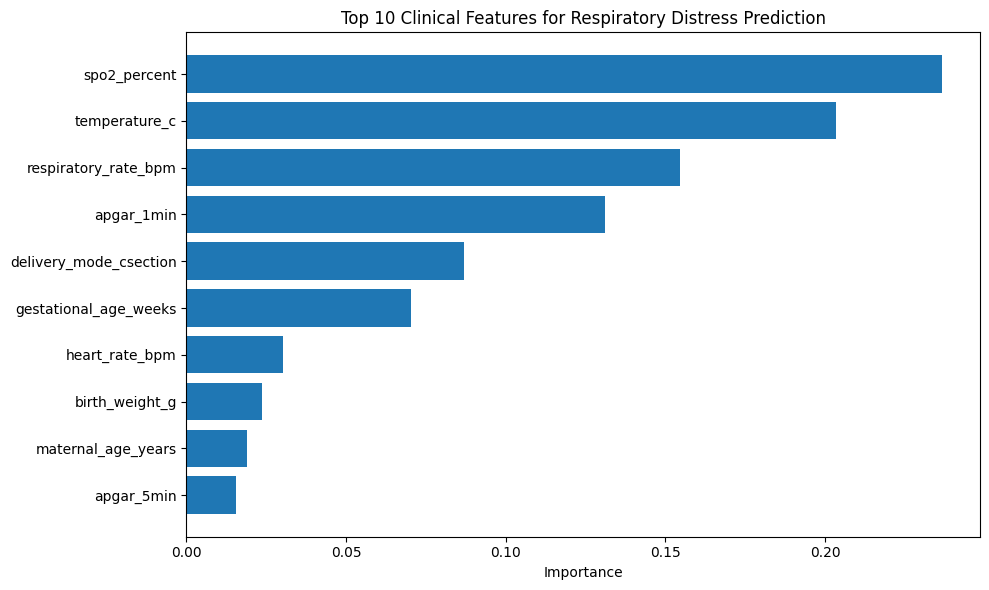

In [9]:
# Feature importance
importance = xgb_model.feature_importances_
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': importance
}).sort_values('importance', ascending=False)

print("\n Top 10 Features:")
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['feature'], feature_importance.head(10)['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Clinical Features for Respiratory Distress Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../../reports/figures/model_3_feature_importance.png', dpi=150)
plt.show()

## 10. Hyperparameter Tuning

In [10]:
print("\n" + "="*60)
print(" HYPERPARAMETER TUNING")
print("="*60)

# Parameter grid
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Grid search
grid_search = GridSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='auc'
    ),
    param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train, sample_weight=sample_weights)

print(f"\n Best parameters: {grid_search.best_params_}")
print(f" Best CV AUC: {grid_search.best_score_:.4f}")

# Use best model
best_xgb = grid_search.best_estimator_


 HYPERPARAMETER TUNING
Fitting 3 folds for each of 162 candidates, totalling 486 fits

 Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 100, 'subsample': 0.7}
 Best CV AUC: 0.9915


## 11. Test Set Evaluation


 TEST SET EVALUATION

 Low Burden Scenario:
   Accuracy: 0.9871 (98.71%)
   AUC: 0.9968

 High Burden Scenario:
   Accuracy: 0.9654 (96.54%)
   AUC: 0.9827

 Overall Test Performance:
   Accuracy: 0.9762 (97.62%)
   AUC: 0.9879

 Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      0.98      0.99     19525
   High Risk       0.50      0.90      0.64       475

    accuracy                           0.98     20000
   macro avg       0.75      0.94      0.82     20000
weighted avg       0.99      0.98      0.98     20000



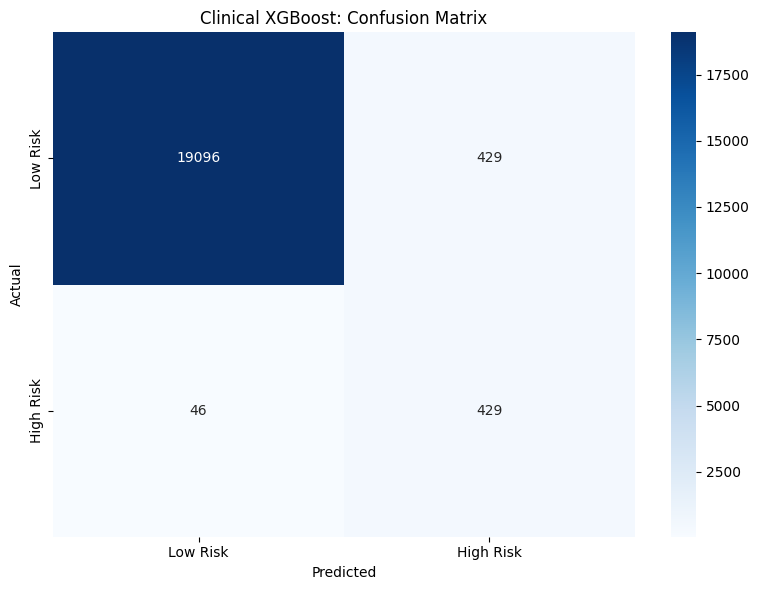

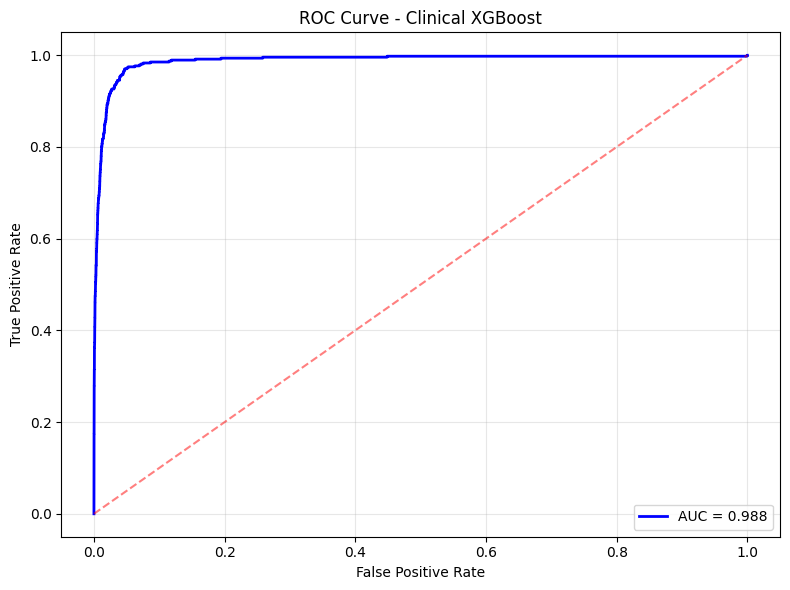

In [11]:
print("\n" + "="*60)
print(" TEST SET EVALUATION")
print("="*60)

# Test on low burden
y_test_low_pred = best_xgb.predict(X_test_low_scaled)
y_test_low_proba = best_xgb.predict_proba(X_test_low_scaled)[:, 1]

low_accuracy = accuracy_score(y_test_low, y_test_low_pred)
low_auc = roc_auc_score(y_test_low, y_test_low_proba)

print(f"\n Low Burden Scenario:")
print(f"   Accuracy: {low_accuracy:.4f} ({low_accuracy*100:.2f}%)")
print(f"   AUC: {low_auc:.4f}")

# Test on high burden
y_test_high_pred = best_xgb.predict(X_test_high_scaled)
y_test_high_proba = best_xgb.predict_proba(X_test_high_scaled)[:, 1]

high_accuracy = accuracy_score(y_test_high, y_test_high_pred)
high_auc = roc_auc_score(y_test_high, y_test_high_proba)

print(f"\n High Burden Scenario:")
print(f"   Accuracy: {high_accuracy:.4f} ({high_accuracy*100:.2f}%)")
print(f"   AUC: {high_auc:.4f}")

# Overall test performance (combine low and high)
X_test = np.vstack([X_test_low_scaled, X_test_high_scaled])
y_test = np.concatenate([y_test_low, y_test_high])
y_test_pred = best_xgb.predict(X_test)
y_test_proba = best_xgb.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"\n Overall Test Performance:")
print(f"   Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   AUC: {test_auc:.4f}")

# Classification report
print("\n Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Low Risk', 'High Risk']))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
plt.title('Clinical XGBoost: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../../reports/figures/model_3_confusion_matrix.png', dpi=150)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {test_auc:.3f}')
plt.plot([0, 1], [0, 1], 'r--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Clinical XGBoost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../reports/figures/model_3_roc_curve.png', dpi=150)
plt.show()

## 12. Save Predictions for Fusion

In [12]:
# Save model
joblib.dump(best_xgb, "../models/model_3_clinical_xgboost.pkl")
print(" Model saved: models/model_3_clinical_xgboost.pkl")

# Save feature names
np.save("../models/model_3_feature_names.npy", feature_columns)
print(" Feature names saved")

# Save test predictions for fusion
np.save("../../sound_data/model_data/model_3_test_proba.npy", y_test_proba)
np.save("../../sound_data/model_data/model_3_test_labels.npy", y_test)
print(" Test predictions saved for late fusion")

# Save metadata
model_3_metadata = {
    'best_params': grid_search.best_params_,
    'test_accuracy': float(test_accuracy),
    'test_auc': float(test_auc),
    'low_burden_auc': float(low_auc),
    'high_burden_auc': float(high_auc),
    'feature_names': feature_columns,
    'scale_pos_weight': float(scale_pos_weight)
}

import json
with open('../models/model_3_metadata.json', 'w') as f:
    json.dump(model_3_metadata, f, indent=2)

print("\n" + "="*60)
print(" MODEL 3 COMPLETE")
print("="*60)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test AUC: {test_auc:.4f}")
print(f"Low Burden AUC: {low_auc:.4f}")
print(f"High Burden AUC: {high_auc:.4f}")

 Model saved: models/model_3_clinical_xgboost.pkl
 Feature names saved
 Test predictions saved for late fusion

 MODEL 3 COMPLETE
Test Accuracy: 97.62%
Test AUC: 0.9879
Low Burden AUC: 0.9968
High Burden AUC: 0.9827
